# OCR по crop-ам из classical layout segmentation

Эта тетрадка берёт результаты `classical_layout_segmentation.ipynb`:

```text
outputs/classical_layout/<page_name>/connected_components/
  crops/block_000.png
  crops/block_001.png
  metadata.json
```

и запускает **baseline** OCR по каждому crop-у в порядке `order` из `metadata.json`.

На выходе сохраняются:

```text
ocr_results.json
ocr_text.txt
ocr_text.md
```

## 1. Установка зависимостей

In [ ]:
%pip install -q "numpy<2.4,>=1.24" "pandas==2.2.2" "pillow==11.1.0"
%pip uninstall -y paddlepaddle paddlepaddle-gpu
%pip install -q "paddlepaddle==3.2.2"
%pip install -q "paddleocr==3.4.1"

print("Установка завершена. Если Colab попросит restart runtime, сделайте restart и продолжайте ниже.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.3/189.3 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.5/80.5 kB 5.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.1/88.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 767.5/767.5 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 M

## 2. Импорты и пути

In [ ]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

In [34]:
PROJECT_ROOT = Path('/content') if Path('/content').exists() else Path('..').resolve()

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception as exc:
    print('Drive не подключён или это не Colab:', exc)

CANDIDATE_OUTPUT_DIRS = [
    Path('/content/drive/MyDrive/Avar OCR ANN/classical_layout'),
    PROJECT_ROOT / 'classical_layout',
]

metadata_files = []
for root in CANDIDATE_OUTPUT_DIRS:
    if root.exists():
        metadata_files.extend(root.rglob('metadata.json'))

metadata_files = sorted(set(metadata_files))
if not metadata_files:
    raise FileNotFoundError(
        'Не нашла metadata.json. Сначала сохраните crop-ы в classical_layout_segmentation.ipynb.'
    )

print('Найдено metadata.json:', len(metadata_files))
for i, path in enumerate(metadata_files[:20]):
    print(i, path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Найдено metadata.json: 1
0 /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/metadata.json


## 3. Выбор страницы и проверка crop-ов

In [36]:
METADATA_INDEX = 0
metadata_path = metadata_files[METADATA_INDEX]
page_dir = metadata_path.parent
metadata = json.loads(metadata_path.read_text(encoding='utf-8'))

blocks = sorted(metadata.get('blocks', []), key=lambda b: b.get('order', 0))
if not blocks:
    raise ValueError(f'В {metadata_path} нет blocks')

print('metadata:', metadata_path)
print('page_dir:', page_dir)
print('blocks:', len(blocks))

blocks_df = pd.DataFrame(blocks)
display(blocks_df.head())

metadata: /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/metadata.json
page_dir: /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components
blocks: 22


,order,column,bbox,area,crop_path
0,0,0,"[87, 82, 331, 117]",6703,/content/drive/MyDrive/Avar OCR ANN/classical_...
1,1,0,"[120, 171, 493, 203]",8860,/content/drive/MyDrive/Avar OCR ANN/classical_...
2,2,0,"[85, 225, 992, 294]",47742,/content/drive/MyDrive/Avar OCR ANN/classical_...
3,3,0,"[85, 302, 1029, 363]",50222,/content/drive/MyDrive/Avar OCR ANN/classical_...
4,4,0,"[80, 391, 444, 462]",19152,/content/drive/MyDrive/Avar OCR ANN/classical_...


In [38]:
N_PREVIEW = 8

for block in blocks[:N_PREVIEW]:
    crop_path = Path(block['crop_path'])
    if not crop_path.exists():
        # Если metadata была перенесена между Colab/Drive/локальной средой,
        # пробуем найти crop по имени рядом с metadata.json.
        crop_path = page_dir / 'crops' / Path(block['crop_path']).name
    print(f"order={block['order']} bbox={block.get('bbox')} file={crop_path.name}")
    # display(Image(filename=str(crop_path), width=600))

order=0 bbox=[87, 82, 331, 117] file=block_000.png
order=1 bbox=[120, 171, 493, 203] file=block_001.png
order=2 bbox=[85, 225, 992, 294] file=block_002.png
order=3 bbox=[85, 302, 1029, 363] file=block_003.png
order=4 bbox=[80, 391, 444, 462] file=block_004.png
order=5 bbox=[79, 474, 455, 1058] file=block_005.png
order=6 bbox=[79, 1317, 456, 2144] file=block_006.png
order=7 bbox=[79, 2142, 456, 2322] file=block_007.png


## 4. Инициализация OCR

In [39]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    # text_recognition_model_name='PP-OCRv5_mobile_rec',
    # text_recognition_model_name='cyrillic_PP-OCRv3_mobile_rec',
    text_recognition_model_name='cyrillic_PP-OCRv5_mobile_rec',
    text_detection_model_name='PP-OCRv5_mobile_det',
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False,
    device='cpu',
)

print('OCR готов')

Creating model: ('PP-OCRv5_mobile_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_mobile_det`.
Creating model: ('cyrillic_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/cyrillic_PP-OCRv5_mobile_rec`.


OCR готов


In [40]:
def resolve_crop_path(block: dict) -> Path:
    crop_path = Path(block['crop_path'])
    if crop_path.exists():
        return crop_path
    fallback = page_dir / 'crops' / crop_path.name
    if fallback.exists():
        return fallback
    raise FileNotFoundError(f'Не найден crop: {crop_path} или {fallback}')


def extract_text_from_paddle_result(result) -> tuple[str, list[dict]]:
    """Return plain text and line-level details from PaddleOCR 3.x results."""
    lines = []
    details = []

    for page_res in result:
        # PaddleOCR 3.x Result object has .json['res'].
        if hasattr(page_res, 'json'):
            data = page_res.json.get('res', page_res.json)
        elif isinstance(page_res, dict):
            data = page_res.get('res', page_res)
        else:
            continue

        rec_texts = data.get('rec_texts', []) or []
        rec_scores = data.get('rec_scores', []) or []
        rec_boxes = data.get('rec_boxes', []) or []

        for i, text in enumerate(rec_texts):
            score = float(rec_scores[i]) if i < len(rec_scores) else None
            box = rec_boxes[i].tolist() if hasattr(rec_boxes, 'tolist') else (rec_boxes[i] if i < len(rec_boxes) else None)
            lines.append(text)
            details.append({'text': text, 'score': score, 'box': box})

    return '\n'.join(lines), details

## 5. OCR по crop-ам


In [41]:
MAX_BLOCKS = None
blocks_to_process = blocks[:MAX_BLOCKS] if MAX_BLOCKS else blocks

ocr_results = []
for block in blocks_to_process:
    crop_path = resolve_crop_path(block)
    print(f"OCR block_{block['order']:03d}: {crop_path.name}")

    result = ocr.predict(str(crop_path))
    text, lines = extract_text_from_paddle_result(result)

    ocr_results.append({
        'order': int(block['order']),
        'column': int(block.get('column', -1)),
        'bbox': block.get('bbox'),
        'crop_path': str(crop_path),
        'text': text,
        'lines': lines,
    })

print('OCR blocks:', len(ocr_results))

OCR block_000: block_000.png
OCR block_001: block_001.png
OCR block_002: block_002.png
OCR block_003: block_003.png
OCR block_004: block_004.png
OCR block_005: block_005.png
OCR block_006: block_006.png
OCR block_007: block_007.png
OCR block_008: block_008.png
OCR block_009: block_009.png
OCR block_010: block_010.png
OCR block_011: block_011.png
OCR block_012: block_012.png
OCR block_013: block_013.png
OCR block_014: block_014.png
OCR block_015: block_015.png
OCR block_016: block_016.png
OCR block_017: block_017.png
OCR block_018: block_018.png
OCR block_019: block_019.png
OCR block_020: block_020.png
OCR block_021: block_021.png
OCR blocks: 22


## 6. Просмотр результатов

Показываем crop и распознанный текст рядом.

### block_000

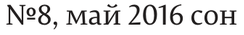

№8, май 2016 сон

--------------------------------------------------------------------------------



### block_001

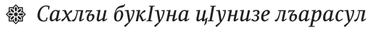

*
Сахлъи букIуна цIунизе лъарасул

--------------------------------------------------------------------------------



### block_002

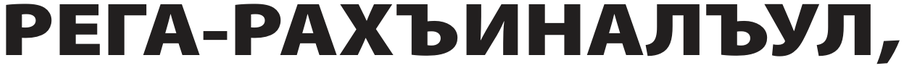

РEGA-P
хъ
ин
ЛЪУЛ
A
A
/

--------------------------------------------------------------------------------



### block_003

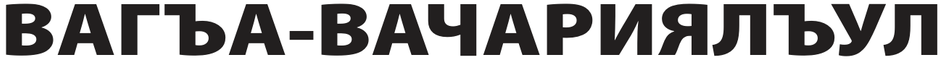

БАГЪ
ЯлъуЛ
A-B
.

--------------------------------------------------------------------------------



### block_004

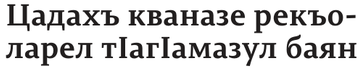

Цадахъ кваназе рекъо-
ларел тIагIамазул баян

--------------------------------------------------------------------------------



### block_005

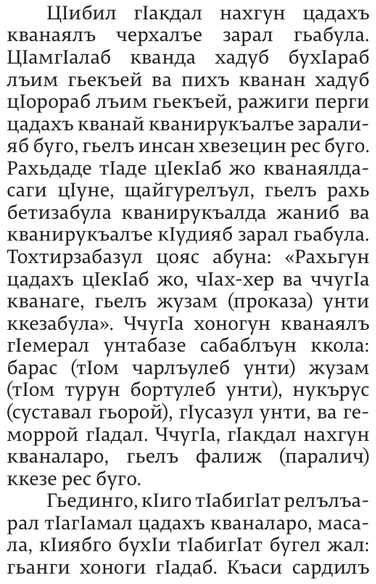

ЦӀибил гIакдал
нахгунцадахъ
кванаялъ черхалъе
 зарал гьабула.
ЦIамгIалаб
 кванда хадуб бухIараб
лъим гьекъей ва пихъ кванан хадуб
цIорораб лъим гьекъей, ражиги перги
цадахъ кванай кванирукъалъе зарали-
яб буго, гьелъ инсан хвезецин рес буго.
Рахьдаде тIаде цIекIаб жо кванаялда-
саги цӀуне, щайгурелъул, гьелъ рахь
бетизабула кванирукъалда жаниб ва
кванирукъалъе кӀудияб зарал гьабула.
Тохтирзабазул цояс абуна: «Рахьгун
цадахъ цIекIаб жо, чIах-хер ва ччугIа
кванаге, гьель жузам (проказа) унти
ккезабула». ЧчугIа хоногун кванаялъ
гIемерал унтабазе сабаблъун ккола:
барас (тIом чарлъулеб унти) жузам
(тIом турун бортулеб унти), нукърус
(суставал гьорой), гIусазул унти, ва ге-
моррой гIадал. ЧчугIа, гIакдал нахгун
кваналаро, гьель фалиж (паралич)
ккезе рес буго.
Гьединго, кӀиго тIабигIат релълъа-
рал тIагIамал цадахъ кваналаро, маса-
ла, кӀиябго бухӀи тIабигIат бугел жал:
гьанги хоноги гIадаб. Къаси сардилъ

--------------------------------------------------------------------------------



### block_006

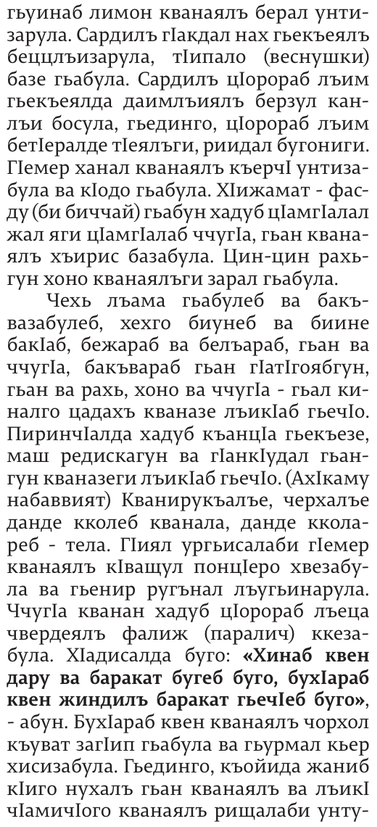

гьуинаб лимон кванаялъ берал унти-
зарула. Сардилъ гIакдал нах гьекъеялъ
беццлъизарула, тIипало (веснушки)
базе гьабула. Сардилъ цIорораб лъим
гьекъеялда даимлъияль берзул кан-
лъи босула, гьединго, цIорораб лъим
бетIералде тIеялъги, риидал бугониги.
ГӀемёр ханал кванаялъ къерчӀ унтиза-
була ва кIодо гьабула. ХӀижамат - фас-
ду (би биччай) гьабун хадуб цӀамгIалал
жал яги цIамгIалаб ччугӀа, гьан квана-
яль хъирис базабула. Цин-цин рахь-
гун хоно кванаялъги зарал гьабула.
Чехь лъама гьабулеб ва бакъ-
вазабулеб, хехго биунеб ва биине
бакIаб, бежараб ва белъараб, гьан ва
ччугӀа, бакъвараб гьан гIатIгоябгун,
гьан ва рахь, хоно ва ччугIа - гьал ки-
налго цадахъ кваназе лъикIаб гьечIо.
ПиринчIалда хадуб къанцIа гьекъезе,
маш редискагун ва гIанкIудал гьан-
гун кваназеги лъикӀаб гьечIо. (АхӀкаму
набаввият) Кванирукъалъе, черхалъе
данде кколеб кванала, данде ккола-
реб - тела. ГIиял ургьисалаби гIемер
кванаяль кІващул понцIеро хвезабу-
ла ва гьенир ругънал лъугьинарула.
ЧчугIа кванан хадуб цIоро

### block_007

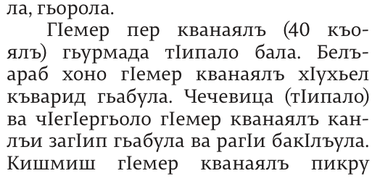

ла, гьорола.
ГIемер пер кванаяль (40 къо-
ялъ)
гьурмада тIипало бала. Бель-
араб хоно гIемер кванаяль хIухьел
къварид гьабула. Чечевица (тӀипало)
ва чIегIергьоло гIемер кванаялъ кан-
лъи загIйп гьабула ва рагӀи бакIлъула.
Кишмиш гIемер кванаяль пикру

--------------------------------------------------------------------------------



In [ ]:
N_SHOW = 8

for item in ocr_results[:N_SHOW]:
    display(Markdown(f"### block_{item['order']:03d}"))
    display(Image(filename=item['crop_path'], width=600))
    print(item['text'] if item['text'] else '[empty]')
    print('\n' + '-' * 80 + '\n')

## 7. Сохранение OCR результатов

Сохраняем:

- `ocr_results.json` — структурированный результат по блокам;
- `ocr_text.txt` — простой текст;
- `ocr_text.md` — markdown с заголовками блоков.

In [42]:
ocr_json_path = page_dir / 'ocr_results.json'
ocr_txt_path = page_dir / 'ocr_text.txt'
ocr_md_path = page_dir / 'ocr_text.md'
manual_md_path = page_dir / 'manual_corrections.md'

ocr_payload = {
    'ocr_model_name': globals().get('OCR_MODEL_NAME'),
    'page_dir': str(page_dir),
    'results': ocr_results,
}

ocr_json_path.write_text(
    json.dumps(ocr_payload, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

with open(ocr_txt_path, 'w', encoding='utf-8') as f:
    for item in ocr_results:
        f.write(f"\n\n### block_{item['order']:03d}\n")
        f.write(item['text'])

with open(ocr_md_path, 'w', encoding='utf-8') as f:
    f.write(f"# OCR results: {page_dir.name}\n\n")
    f.write(f"OCR model: `{globals().get('OCR_MODEL_NAME')}`\n\n")
    for item in ocr_results:
        crop_name = Path(item['crop_path']).name
        f.write(f"## block_{item['order']:03d}\n\n")
        f.write(f"Crop: `{crop_name}`  \n")
        f.write(f"BBox: `{item['bbox']}`\n\n")
        f.write('```text\n')
        f.write(item['text'])
        f.write('\n```\n\n')

with open(manual_md_path, 'w', encoding='utf-8') as f:
    f.write(f"# Manual OCR Corrections: {page_dir.name}\n\n")
    f.write(f"OCR model: `{globals().get('OCR_MODEL_NAME')}`\n\n")
    f.write("Правьте только блоки `Corrected`. Блок `OCR` оставлен как исходный baseline.\n\n")
    for item in ocr_results:
        order = item['order']
        crop_path = Path(item['crop_path'])
        crop_name = crop_path.name
        text = item.get('text', '') or ''
        f.write(f"## block_{order:03d}\n\n")
        f.write(f"![block_{order:03d}](crops/{crop_name})\n\n")
        f.write(f"Crop: `crops/{crop_name}`  \n")
        f.write(f"BBox: `{item['bbox']}`\n\n")
        f.write('OCR:\n\n')
        f.write('```text\n')
        f.write(text)
        f.write('\n```\n\n')
        f.write('Corrected:\n\n')
        f.write('```text\n')
        f.write(text)
        f.write('\n```\n\n')
        f.write('---\n\n')

print('Saved:')
print('-', ocr_json_path)
print('-', ocr_txt_path)
print('-', ocr_md_path)
print('-', manual_md_path)

Saved:
- /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/ocr_results.json
- /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/ocr_text.txt
- /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/ocr_text.md
- /content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components/manual_corrections.md


## 8. Скачать результаты архивом

In [43]:
try:
    from google.colab import files
    zip_path = page_dir.with_suffix('.zip')
    if zip_path.exists():
        zip_path.unlink()
    import shutil
    shutil.make_archive(str(zip_path.with_suffix('')), 'zip', page_dir)
    print(zip_path)
    files.download(str(zip_path))
except Exception as exc:
    print('Скачивание доступно только в Colab:', exc)

/content/drive/MyDrive/Avar OCR ANN/classical_layout/0_tlyarata_8_-na_pechat_page_003/connected_components.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Обзор дерева папки

In [46]:
import os

def list_files(startpath, max_depth=3):
    """Рекурсивный обход папок с ограничением глубины"""

    def _list_files(current_path, depth=0):
        if depth > max_depth:
            return

        try:
            items = os.listdir(current_path)
            indent = "  " * depth

            for item in sorted(items):  # сортировка для удобства
                full_path = os.path.join(current_path, item)

                if os.path.isdir(full_path):
                    print(f"{indent}📁 {item}/")
                    _list_files(full_path, depth + 1)
                else:
                    print(f"{indent}📄 {item}")

        except PermissionError:
            print(f"{indent}❌ Нет доступа к {current_path}")
        except FileNotFoundError:
            print(f"{indent}❌ Папка не найдена: {current_path}")

    print(f"📁 Структура {startpath}")
    print("=" * 50)
    _list_files(startpath)

# Использование
path = '/content/drive/MyDrive/Avar OCR ANN/classical_layout'
list_files(path, max_depth=3)

📁 Структура /content/drive/MyDrive/Avar OCR ANN/classical_layout
📁 0_tlyarata_8_-na_pechat_page_003/
  📁 connected_components/
    📁 crops/
      📄 block_000.png
      📄 block_001.png
      📄 block_002.png
      📄 block_003.png
      📄 block_004.png
      📄 block_005.png
      📄 block_006.png
      📄 block_007.png
      📄 block_008.png
      📄 block_009.png
      📄 block_010.png
      📄 block_011.png
      📄 block_012.png
      📄 block_013.png
      📄 block_014.png
      📄 block_015.png
      📄 block_016.png
      📄 block_017.png
      📄 block_018.png
      📄 block_019.png
      📄 block_020.png
      📄 block_021.png
    📄 debug_connected_components.png
    📄 manual_corrections.md
    📄 metadata.json
    📄 ocr_results.json
    📄 ocr_text.md
    📄 ocr_text.txt
